In [1]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [ ]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    graph_gen,
    video_tools)

from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as videovis


In [3]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
QA_SGG = WORK_DIR / "outputs/gu_on_sgg_qbias_onlyq_u4_gemma3:4b-it-qat_20250708_22:14:00.jsonl"
SGG_GRAPHS = WORK_DIR / "outputs/sgg/sggm_qbias_onlyq_gemma3:4b-it-qat_20250707_21:59:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Prompts

### SGG

In [4]:
with open(WORK_DIR / "data/prompts/graph-gen/user_prompt_oneframe_per_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


You are an intelligent video comprehension model and are going to receive as input a frame extracted from a video. You need to analyze and describe the scene unfolding in the frame following these guidelines:

1. Look for recurring objects;
2. Pay attention to how the person interacts with its environment;
3. Presume the directional movement of the people and objects in the image;
4. Pay attention to the atomic and fine grained movement
5. Deduce the intentions and motives behind the actions;
6. Identify unusual actions accurately.


In [5]:
with open(WORK_DIR / "data/prompts/graph-gen/format_instructions_oneframe_per_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


Now organize the objects and relationships you identified into a formal scene graph using this format:
object1 ---- relationship ---- object2

The list of relationship predicates should be introduced by the tag <scene_graph> and terminated by the tag </scene_graph>
For example:
woman ---- sitting_on ---- chair
dog ---- lying_under ---- table
book ---- on_top_of ---- shelf

Please follow these guidelines:
1. Create an appropriate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relationships between objects
5. Verify that all objects you identified in step 1 appear in at least one relationship

Your scene graph:


### Graph understanding from the SGG

Launch script:

```bash
python3 -m star_code.src.main \
  --task graph-understanding \
  --model gemma3:4b-it-qat \
  --model-options star_code/ollama_model_options.json \
  --prompt-type mcq_zs_cot \
  --sys-prompt star_code/data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt \
  --user-prompt star_code/data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt \
  --mode chat \
  --reply-file star_code/data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt \
  --dataset-type star \
  --input-file star_code/data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json \
  --stsg-file star_code/outputs/sgg/sggm2_qbias_onlyq_gemma3:4b-it-qat_20250707_21:59:00.jsonl \
  --output-file star_code/outputs/gu_on_sggm2_qbias_onlyq_u3_gemma3:4b-it-qat_20250709_23:14:00.jsonl 
```

In [6]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


You need to respond to reasoning questions by making logical inference on sequence of Scene-Graphs extracted from frames belonging to a video, called a Spatio-Temporal Scene Graph.

IMPORTANT CLARIFICATIONS:
- You will receive a question and Spatio-Temporal Scene-Graph
- Each Scene-Graph is a static symbolic representation of the scene unfolding in the frame
- The Scene-Graphs are ordered chronologically
- The Scene-Graph is represented as a set of tuple in the format: subject - relationship - object
- The Spatio-Temporal Scene-Graph is a cornologically sorted list of Scene-Graphs

INSTRUCTIONS:
- Read the entire Spatio-Temporal Scene-Graphs in chronological order and pay attention at the order of how events unfold.
- Read the question and reason about the answer step by step.
- In your answer include key events or relationships that help you in determing the correct answer.
- Be careful to reproduce the chosen alternative as it is presented.


In [7]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt") as f:
    pr = f.read()
    
print(pr)
    


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
{stsg}
</STSG>

Given the following question:
<Q>
{question}
<Q>

And the following alternatives:
<Alternatives>
A. {c1}
B. {c2}
C. {c3}
D. {c4}
</Alternatives>

Provide an answer to the above question reasoning step by step on the Spatio-Temporal Scene-Graph (STSG) and choosing one of the alternatives. 

In answering the question please be sure to operate according to the following guidlines:
1. Question Interpretation: Clearly state what the question is asking
2. STSG Analysis: Carefully examine the spatial and temporal relationships in the scene graph
3. Alternative Evaluation: For each option (A, B, C, D), explain whether it matches the STSG evidence
4. Reasoning: Provide clear logical step by step reasoning leading to your conclusion
5. Conclusion: Declare the logical conclusion to your reasoning in the above step
6. Consistency Check: B

In [8]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



## Loading GT

In [9]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


## Loading Generated STSG

In [10]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df


,question_id,chat_history,stsg
0,Feasibility_T5_102,"[{'role': 'user', 'content': 'You are an intel...",Here’s the spatio-temporal scene graph based o...
1,Feasibility_T2_860,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
2,Feasibility_T2_556,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
3,Prediction_T1_2539,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
4,Prediction_T4_1253,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
...,...,...,...
1034,Interaction_T1_8913,"[{'role': 'user', 'content': 'You are an intel...",Here’s the spatio-temporal scene graph based o...
1035,Interaction_T1_8967,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
1036,Interaction_T2_1847,"[{'role': 'user', 'content': 'You are an intel...",Here’s the spatio-temporal scene graph based o...
1037,Interaction_T2_3423,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...


In [11]:
print(sgg_df.iloc[495]['chat_history'][0]['content'])


You are an intelligent video comprehension model. You will receive as input:
- A sequence of images (frames) extracted from a video
- A question about the video

Your task is not to answer the question but to analyze and describe the scene in enough detail such that your description alone is enough to answer the question, even if the images themselves are not available.
In generating your description, follow these guidelines:


1. Look for recurring objects;
2. Note that the same object may look different across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interact with its environment;
4. Understand the directional movement of the people and objects;
5. Carefully analyze the chronological sequence of the events;
6. Pay attention to the atomic and fine-grained movement, pose and ac

## Loading predicted answers evaluation

In [12]:
pred_sgg_df = rp.gemma3_ans_extract(QA_SGG)


Total answers: 1037
Answers following JSON template: 1035
Percentage following JSON template: 99.81%
Answer following the template: 1032
99.71% of the total

Only 3 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


In [13]:
pred_sgg_df


,chat_history,json_mask,contains_answer,answer
id,,,,
Feasibility_T5_102,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Feasibility_T2_860,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Feasibility_T2_556,"[{'role': 'user', 'content': 'Please carefully...",True,True,Tidy up the closet/cabinet.
Prediction_T1_2539,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Prediction_T4_1253,"[{'role': 'user', 'content': 'Please carefully...",True,True,The shoe.
...,...,...,...,...
Interaction_T1_8913,"[{'role': 'user', 'content': 'Please carefully...",True,True,The paper/notebook.
Interaction_T1_8967,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Interaction_T2_1847,"[{'role': 'user', 'content': 'Please carefully...",True,True,Took.


In [14]:
print(pred_sgg_df.iloc[0]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s the spatio-temporal scene graph based on the analysis:

<stsg>
Frame 0:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 1:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 2:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 3:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
</stsg>
</STSG>

Given the following question:
<Q>
Which

In [15]:
print(pred_sgg_df.iloc[0]['chat_history'][-1]['content'])


```json
{"answer": "E. None of the others."}
```


In [16]:
~pred_sgg_df[pred_sgg_df["contains_answer"]]['answer'].str.startswith("None")


id
Feasibility_T5_102     False
Feasibility_T2_860     False
Feasibility_T2_556      True
Prediction_T1_2539     False
Prediction_T4_1253      True
                       ...  
Interaction_T1_8913     True
Interaction_T1_8967    False
Interaction_T2_1847     True
Interaction_T2_3423     True
Interaction_T4_4181    False
Name: answer, Length: 1032, dtype: bool

In [17]:
pred_sgg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_sgg_df.loc[pred_sgg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          296        25.68%  
Sequence             287        28.22%  
Prediction           233        18.88%  
Feasibility          216        20.83%  

Average             1032        23.84%  


In [18]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        99.33%  
Sequence             291        98.63%  
Prediction           239        97.49%  
Feasibility          220        98.18%  
Overall             1048        98.47%  


#### Excluding None of the others

In [19]:
pred_sgg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df3 = gt_df.join(
    pred_sgg_df[pred_sgg_df["contains_answer"] & ~pred_sgg_df['pred_text'].str.startswith("None")], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df3, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          170        44.71%  
Sequence             152        53.29%  
Prediction           100        44.00%  
Feasibility          112        40.18%  

Average              534        46.07%  


In [20]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        99.33%  
Sequence             291        98.63%  
Prediction           239        97.49%  
Feasibility          220        98.18%  
Overall             1048        98.47%  


### Why is the accuracy with the generated SG as base so low?

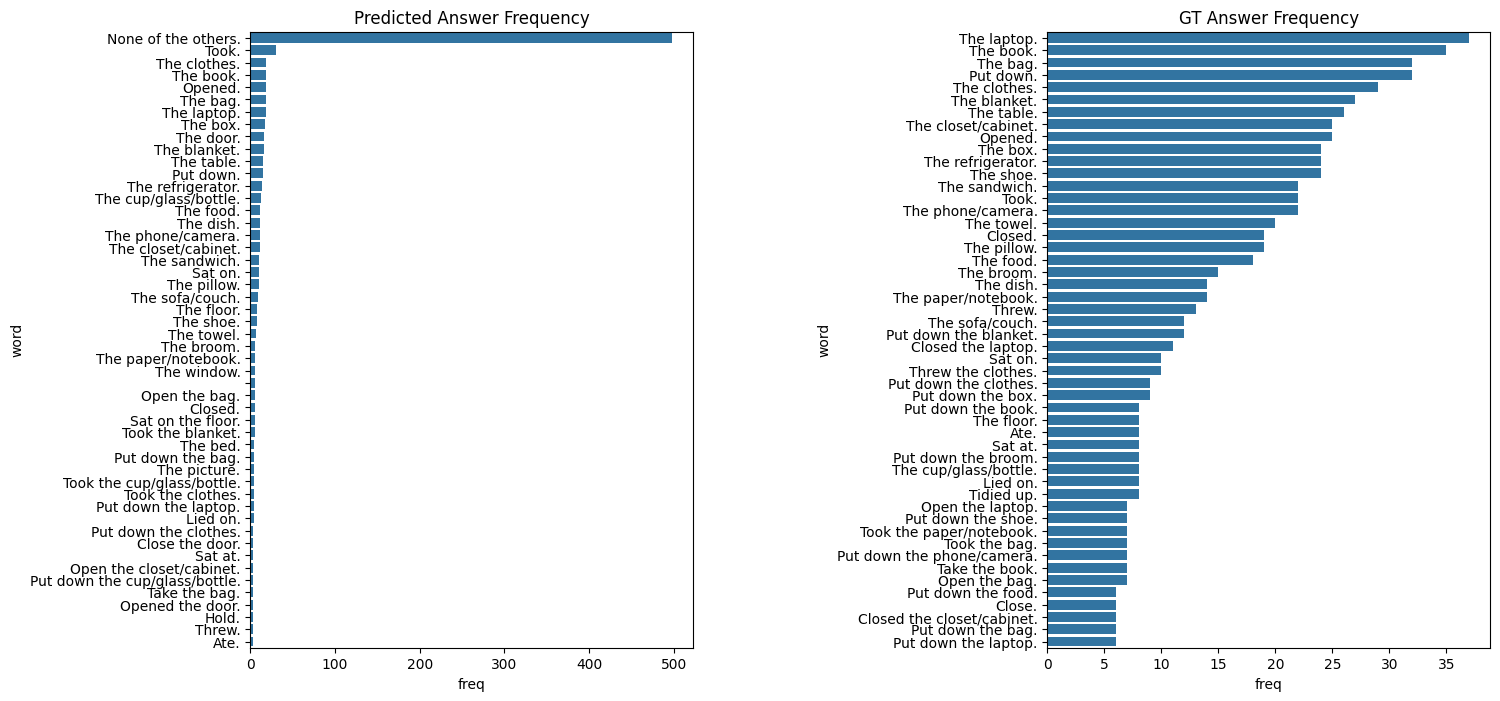

In [21]:
freq_pred = pred_sgg_df['pred_text'].value_counts().reset_index()
freq_pred.columns = ["word", "freq"]

freq_gt = gt_df['text'].value_counts().reset_index()
freq_gt.columns = ["word", "freq"]


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.8}   # adjust wspace to taste
)

sns.barplot(
    data=freq_pred.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[0]
)
axes[0].set_title("Predicted Answer Frequency")

sns.barplot(
    data=freq_gt.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[1]
)

axes[1].set_title("GT Answer Frequency")
plt.show()


That's way. For > half of the Q the model answers with None of the others.

<Axes: xlabel='freq', ylabel='word'>

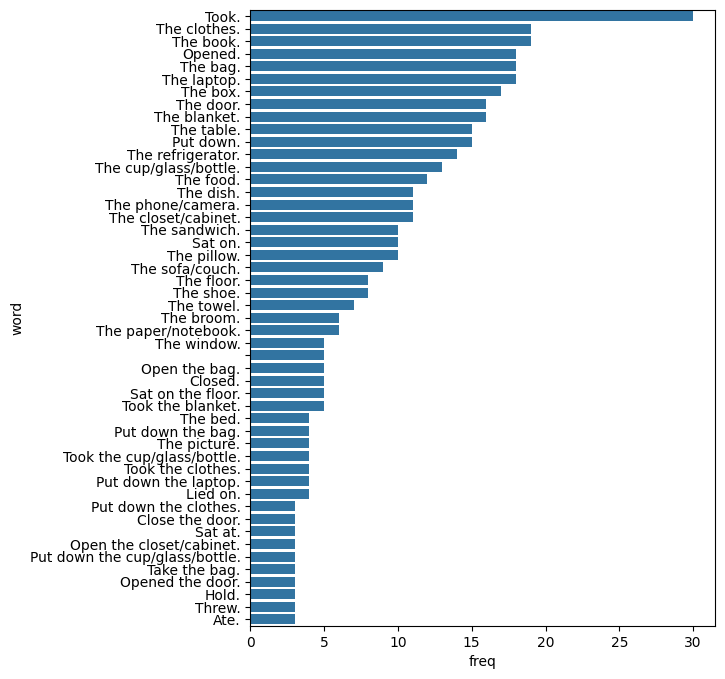

In [22]:
plt.figure(figsize=(6, 8))
sns.barplot(data=freq_pred.iloc[1:50], x='freq', y='word')


### Token length analysis

In [23]:
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    auth_token=hugg_auth_token
)


### sgg len

In [24]:
hard_pattern = re.compile(r"(<stsg>.*</stsg>)", re.DOTALL)
relaxed_pattern = re.compile(r"(<stsg>.*(?:</stsg>|</scene_graph>))", re.DOTALL)


In [25]:
hard_mask = sgg_df["stsg"].str.contains(hard_pattern, regex=True)
relaxed_mask = sgg_df["stsg"].str.contains(relaxed_pattern, regex=True)

print(f"Hard mask: {hard_mask.sum()}")
print(f"Relaxed mask: {relaxed_mask.sum()}")


Hard mask: 998
Relaxed mask: 1033


/tmp/ipykernel_1439820/1981089467.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hard_mask = sgg_df["stsg"].str.contains(hard_pattern, regex=True)
/tmp/ipykernel_1439820/1981089467.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  relaxed_mask = sgg_df["stsg"].str.contains(relaxed_pattern, regex=True)


In [26]:
print(sgg_df[~hard_mask & relaxed_mask]['stsg'].iloc[0])


Here’s a spatio-temporal scene graph representing the events observed in the video, adhering to your specified format:

<stsg>
Frame 0:
<scene_graph>
person ---- standing_near ---- washing_machine
washing_machine ---- located_in ---- laundry_room
laundry_room ---- containing ---- washing_machine
laundry_room ---- containing ---- dryer
laundry_room ---- containing ---- hamper
laundry_room ---- containing ---- clock
laundry_room ---- containing ---- heart_decoration
laundry_room ---- containing ---- trash_can
laundry_room ---- containing ---- cleaning_supplies
</scene_graph>

Frame 1:
<scene_graph>
person ---- standing_near ---- washing_machine
washing_machine ---- located_in ---- laundry_room
laundry_room ---- containing ---- washing_machine
laundry_room ---- containing ---- dryer
laundry_room ---- containing ---- hamper
laundry_room ---- containing ---- clock
laundry_room ---- containing ---- heart_decoration
laundry_room ---- containing ---- trash_can
laundry_room ---- containing ----

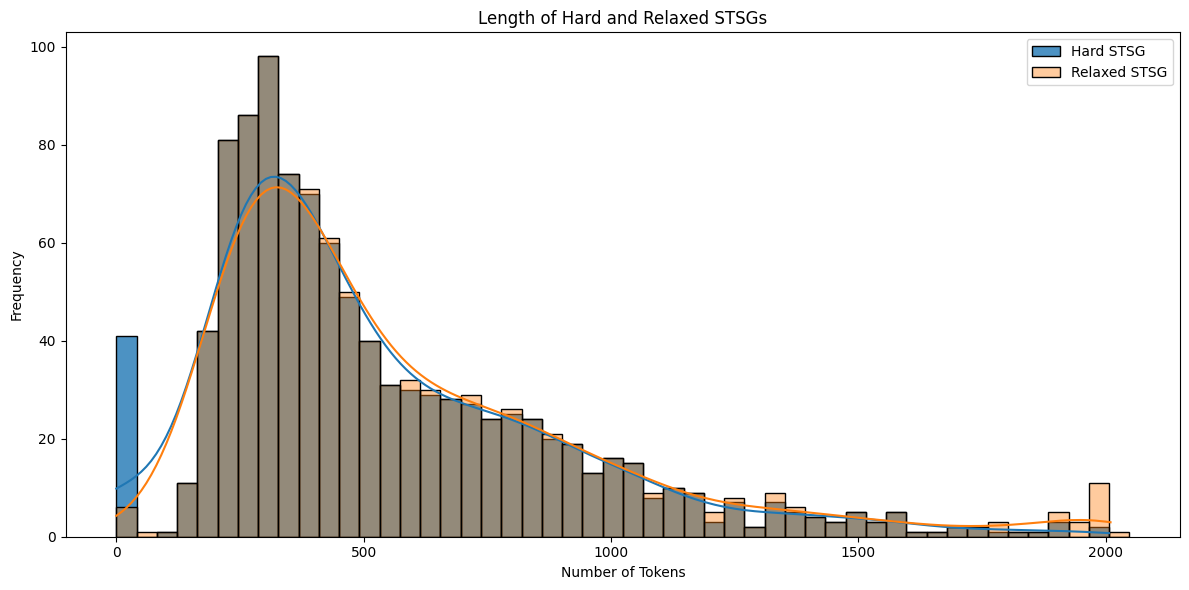

In [27]:
sgg_df['hard'] = sgg_df["stsg"].apply(lambda x: match.group(1) if (match := hard_pattern.search(x)) else "")
sgg_df['relaxed'] = sgg_df["stsg"].apply(lambda x: match.group(1) if (match := relaxed_pattern.search(x)) else "")
sgg_df['hard_len'] = sgg_df['hard'].apply(gemma3_tokenizer.tokenize)
sgg_df['relaxed_len'] = sgg_df['relaxed'].apply(gemma3_tokenizer.tokenize)


plt.figure(figsize=(12, 6))
sns.histplot(sgg_df['hard_len'].apply(len), binrange=(0,2048), bins=50, kde=True, label='Hard STSG', alpha=0.8)
sns.histplot(sgg_df['relaxed_len'].apply(len), binrange=(0,2048), bins=50, kde=True, label='Relaxed STSG', alpha=0.4)
plt.legend()
plt.title("Length of Hard and Relaxed STSGs")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


The peak frequency for hard matches at 0 is symptom of non-matches. As we can imagine the hard constrain pattern is more stringent, consequently leads to 

### Reasoning token length

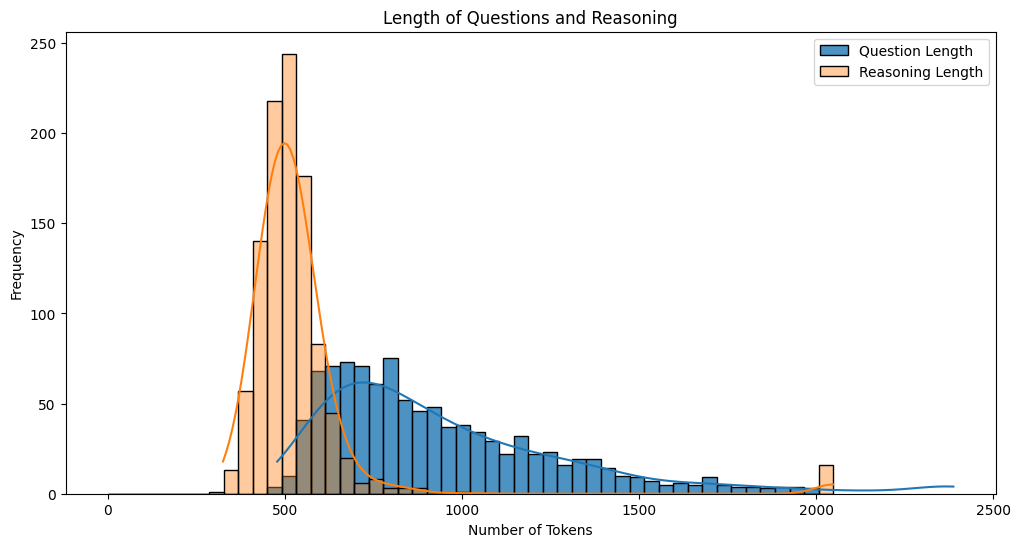

In [28]:
pred_sgg_df['q_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[0]['content'])))
pred_sgg_df['reason_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))

plt.figure(figsize=(12, 6))
sns.histplot(
    pred_sgg_df['q_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Question Length', alpha=0.8)
sns.histplot(
    pred_sgg_df['reason_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Reasoning Length', alpha=0.4)
plt.legend()
plt.title("Length of Questions and Reasoning")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


The `reason_len` is limited to 2048 tokens because the `num_predict` parameter was set to 2048, which acts as the output token cutoff for the model. This means the reasoning output cannot exceed this length, regardless of the input.

On the other hand, `q_len` can exceed this length because it is composed of both the generated STSG (which is itself capped at 2048 tokens) and the question prompt, resulting in a total length that may surpass 2048 tokens.

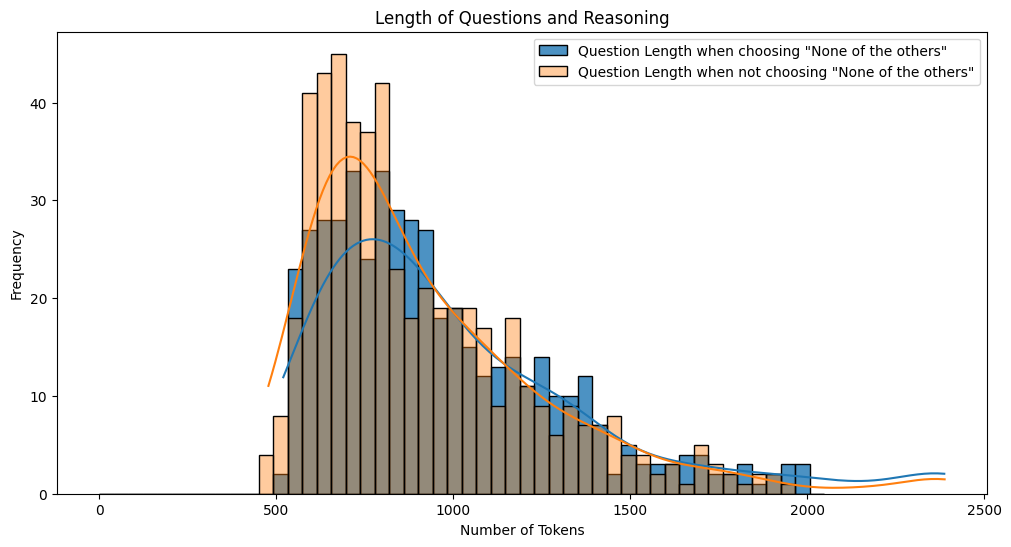

In [29]:
pred_sgg_df['q_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[0]['content'])))
pred_sgg_df['reason_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))

plt.figure(figsize=(12, 6))
sns.histplot(
    pred_sgg_df[pred_sgg_df['pred_text'].str.startswith("None")]['q_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Question Length when choosing "None of the others"', alpha=0.8)
sns.histplot(
    pred_sgg_df[~pred_sgg_df['pred_text'].str.startswith("None")]['q_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Question Length when not choosing "None of the others"', alpha=0.4)
plt.legend()
plt.title("Length of Questions and Reasoning")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


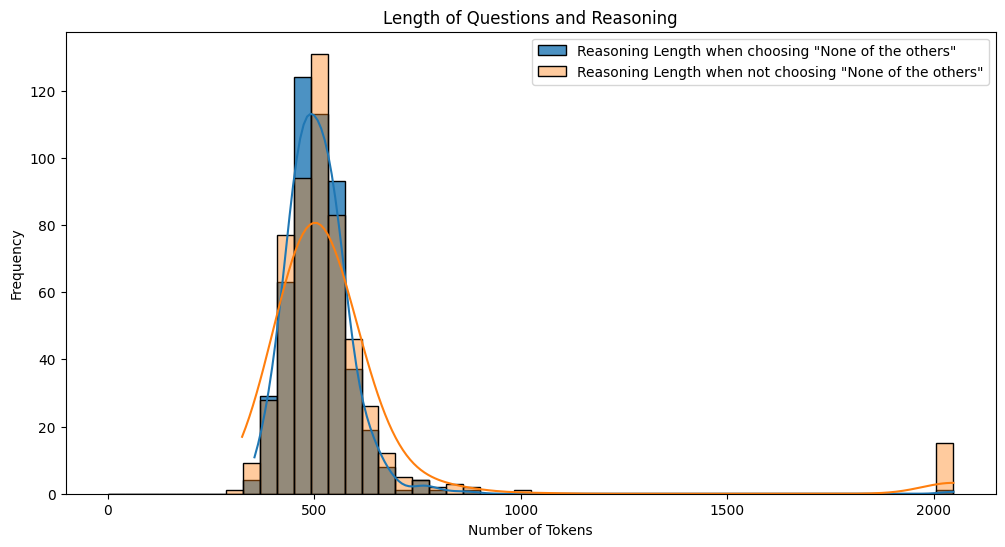

In [30]:
pred_sgg_df['q_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[0]['content'])))
pred_sgg_df['reason_len'] = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))

plt.figure(figsize=(12, 6))
sns.histplot(
    pred_sgg_df[pred_sgg_df['pred_text'].str.startswith("None")]['reason_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Reasoning Length when choosing "None of the others"', alpha=0.8)
sns.histplot(
    pred_sgg_df[~pred_sgg_df['pred_text'].str.startswith("None")]['reason_len'],
    bins=50, binrange=(0,2048),
    kde=True,
    label='Reasoning Length when not choosing "None of the others"', alpha=0.4)
plt.legend()
plt.title("Length of Questions and Reasoning")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


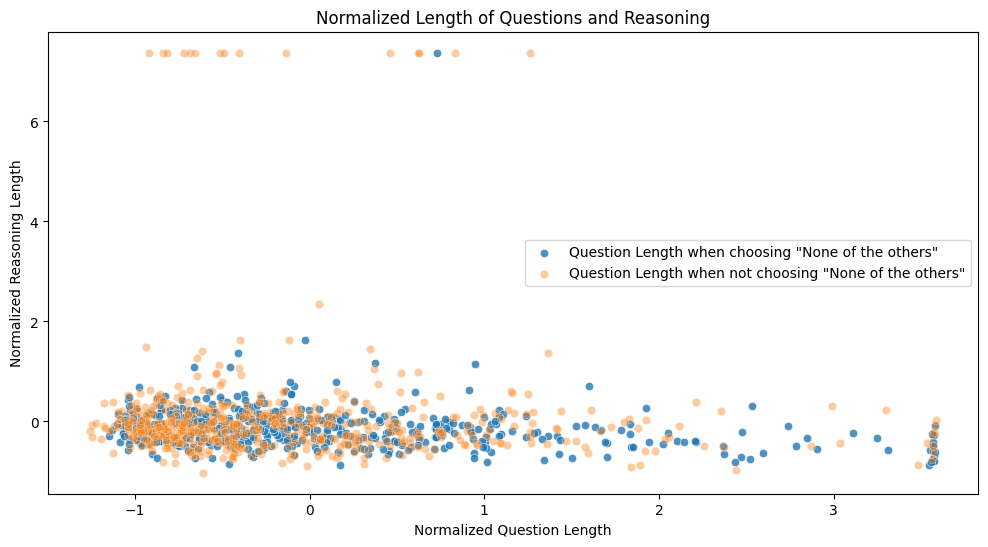

In [31]:
# standardize the reasoning length and q_len then do a scatter plot of both
# distinguishing by using the condition of whether the answer starts with "None" or not
pred_sgg_df['q_len_norm'] = (pred_sgg_df['q_len'] - pred_sgg_df['q_len'].mean()) / pred_sgg_df['q_len'].std()
pred_sgg_df['reason_len_norm'] = (pred_sgg_df['reason_len'] - pred_sgg_df['reason_len'].mean()) / pred_sgg_df['reason_len'].std()
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=pred_sgg_df[pred_sgg_df['pred_text'].str.startswith("None")],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when choosing "None of the others"', alpha=0.8)
sns.scatterplot(
    data=pred_sgg_df[~pred_sgg_df['pred_text'].str.startswith("None")],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when not choosing "None of the others"', alpha=0.4)
plt.legend()
plt.title("Normalized Length of Questions and Reasoning")
plt.xlabel("Normalized Question Length")
plt.ylabel("Normalized Reasoning Length")
plt.show()


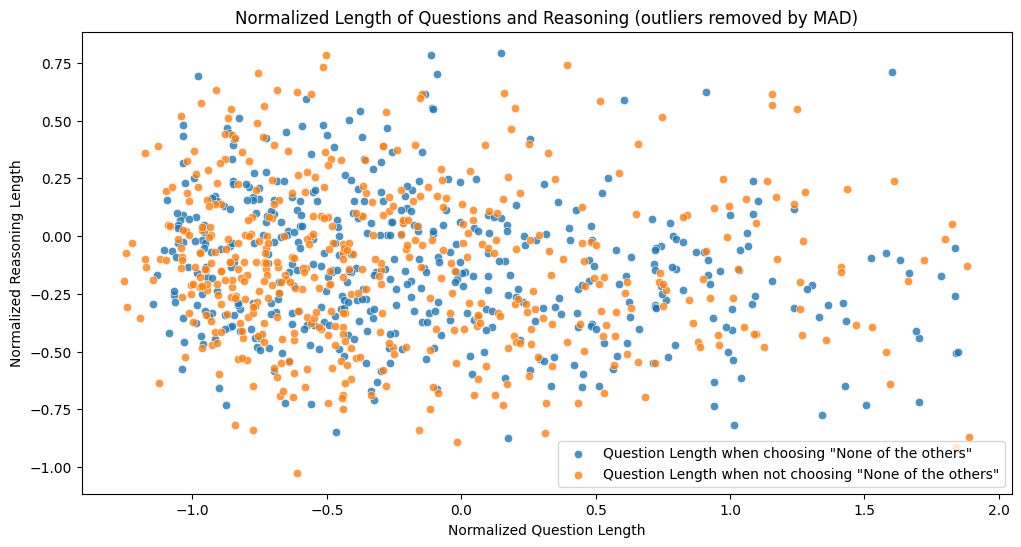

In [32]:
from scipy.stats import median_abs_deviation

# Calculate robust z-score for q_len and reason_len using median and MAD

q_median = pred_sgg_df['q_len'].median()
q_mad = median_abs_deviation(pred_sgg_df['q_len'], scale='normal')
r_median = pred_sgg_df['reason_len'].median()
r_mad = median_abs_deviation(pred_sgg_df['reason_len'], scale='normal')

# Compute robust z-scores
pred_sgg_df['q_len_robust_z'] = (pred_sgg_df['q_len'] - q_median) / q_mad
pred_sgg_df['reason_len_robust_z'] = (pred_sgg_df['reason_len'] - r_median) / r_mad

# Filter out outliers with |robust z| > 3
filtered_robust_df = pred_sgg_df[
    (pred_sgg_df['q_len_robust_z'].abs() <= 3) &
    (pred_sgg_df['reason_len_robust_z'].abs() <= 3)
]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=filtered_robust_df[filtered_robust_df['pred_text'].str.startswith("None")],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when choosing "None of the others"', alpha=0.8)
sns.scatterplot(
    data=filtered_robust_df[~filtered_robust_df['pred_text'].str.startswith("None")],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when not choosing "None of the others"', alpha=0.8)
plt.legend()
plt.title("Normalized Length of Questions and Reasoning (outliers removed by MAD)")
plt.xlabel("Normalized Question Length")
plt.ylabel("Normalized Reasoning Length")
plt.show()


In [33]:
pred_sgg_df['gt_answer'] = gt_df['text']
pred_sgg_df['correct'] = (pred_sgg_df['pred_text'].str.lower() == pred_sgg_df['gt_answer'].str.lower()).astype(int)

pred_sgg_df['correct'].value_counts(normalize=True)


correct
0    0.762777
1    0.237223
Name: proportion, dtype: float64

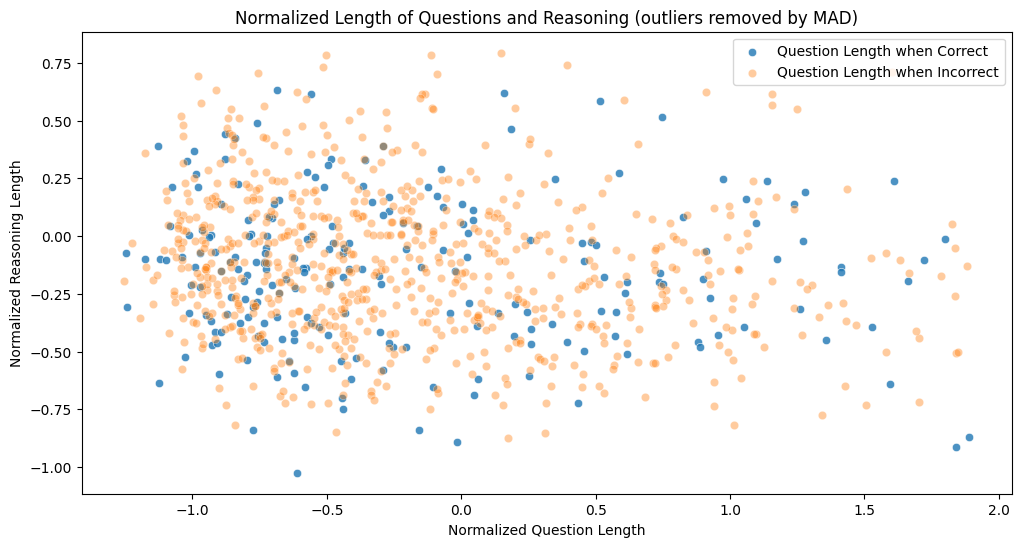

In [34]:
from scipy.stats import median_abs_deviation

# Calculate robust z-score for q_len and reason_len using median and MAD

q_median = pred_sgg_df['q_len'].median()
q_mad = median_abs_deviation(pred_sgg_df['q_len'], scale='normal')
r_median = pred_sgg_df['reason_len'].median()
r_mad = median_abs_deviation(pred_sgg_df['reason_len'], scale='normal')

# Compute robust z-scores
pred_sgg_df['q_len_robust_z'] = (pred_sgg_df['q_len'] - q_median) / q_mad
pred_sgg_df['reason_len_robust_z'] = (pred_sgg_df['reason_len'] - r_median) / r_mad

# Filter out outliers with |robust z| > 3
filtered_robust_df = pred_sgg_df[
    (pred_sgg_df['q_len_robust_z'].abs() <= 3) &
    (pred_sgg_df['reason_len_robust_z'].abs() <= 3)
]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=filtered_robust_df[filtered_robust_df['correct'].astype(bool)],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when Correct', alpha=0.8)
sns.scatterplot(
    data=filtered_robust_df[~filtered_robust_df['correct'].astype(bool)],
    x='q_len_norm', y='reason_len_norm',
    label='Question Length when Incorrect', alpha=0.4)
plt.legend()
plt.title("Normalized Length of Questions and Reasoning (outliers removed by MAD)")
plt.xlabel("Normalized Question Length")
plt.ylabel("Normalized Reasoning Length")
plt.show()


## Inspection

### 1

In [35]:
gt_df['question_id'] = gt_df.index

wrongs = pred_sgg_df[~pred_sgg_df['correct'].astype(bool)].index
fps = 1


In [36]:
idx = wrongs[0]
idx


'Feasibility_T5_102'

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ATV2F.mp4 with start: 0.0, end: 4.0, fps: 1, max_frames: None


	Video Seg:  0.0s - 4.0s


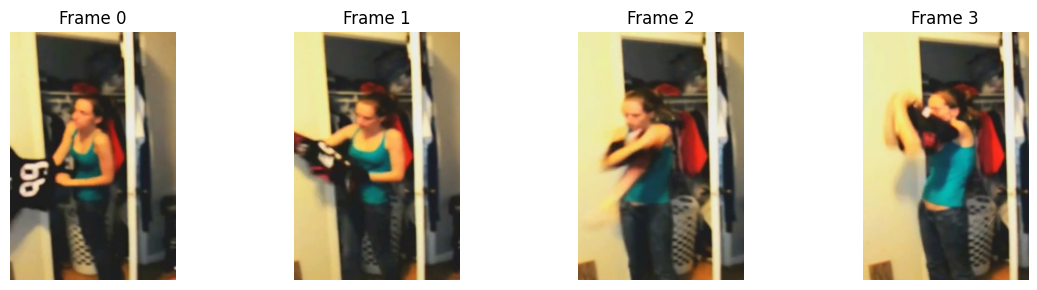

In [37]:
qa_viz.vis_video_frames(gt_df.loc[idx], RAW_VIDEO_DIR, fps=1)


In [ ]:
videovis.Vis_Video(gt_df.loc[idx],
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR
)


	Video Seg:  0.0s - 4.0s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [39]:
pred_sgg_df.loc[idx]


chat_history           [{'role': 'user', 'content': 'Please carefully...
json_mask                                                           True
contains_answer                                                     True
pred_text                                            None of the others.
q_len                                                                551
reason_len                                                           483
q_len_norm                                                      -1.07001
reason_len_norm                                                -0.254137
q_len_robust_z                                                 -1.049589
reason_len_robust_z                                            -0.323193
gt_answer                                                   The clothes.
correct                                                                0
Name: Feasibility_T5_102, dtype: object

In [40]:
qa_viz.compact_print_qa(idx, gt_df, [pred_sgg_df])



┌─ Sample: Feasibility_T5_102 ──────────────────────────────────────────────────────────────
│
│ Question:
│    Which object is the person able to throw after walking through the doorway?
│ Alternatives:
│    0. The bag.
│    1. The book.
│    2. The blanket.
│    3. The clothes.
│
│ Ground Truth:
│    The clothes.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  None of the others. [WRONG]
│    Reasoning:
│        Okay, let's analyze the spatio-temporal scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks which object the person can throw *after* walking through the doorway.  The key is the temporal aspect – the action of throwing must occur *after* the person has moved through the doorway.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes a consistent situation across all three frames.  The person is holding a backpack, and the backpack is located in the doorway. The 

In [41]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s the spatio-temporal scene graph based on the analysis:

<stsg>
Frame 0:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 1:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 2:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
Frame 3:
<scene_graph>
person ---- holding_object ---- backpack
backpack ---- located_in ---- doorway
doorway ---- located_in ---- room
room ---- contains ---- person
</scene_graph>
</stsg>
</STSG>

Given the following question:
<Q>
Which

### 2

In [42]:
idx = wrongs[1]
idx


'Feasibility_T2_860'

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/9J166.mp4 with start: 9.9, end: 17.5, fps: 1, max_frames: None


	Video Seg:  9.9s - 17.5s


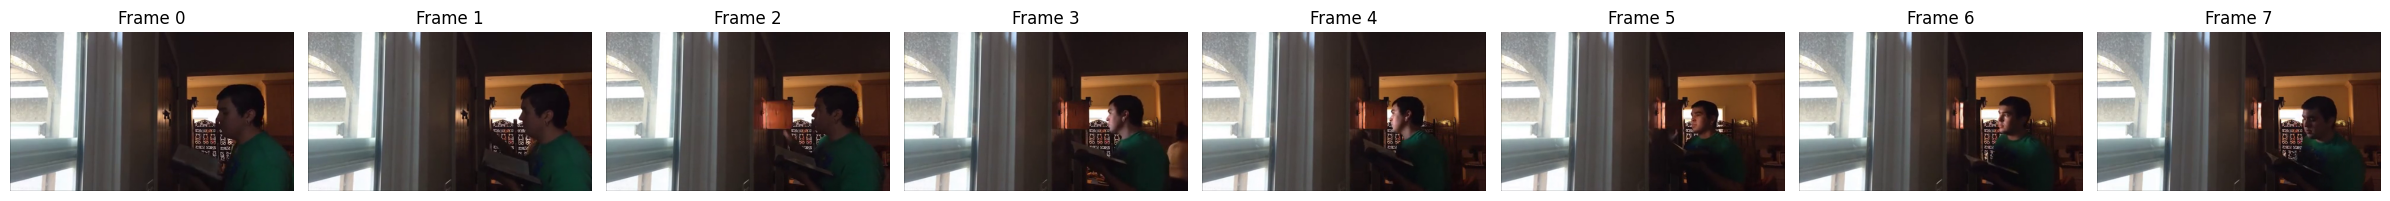

In [43]:
qa_viz.vis_video_frames(gt_df.loc[idx], RAW_VIDEO_DIR, fps=1)


In [ ]:
videovis.Vis_Video(gt_df.loc[idx],
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR
)


	Video Seg:  9.9s - 17.5s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [45]:
qa_viz.compact_print_qa(idx, gt_df, [pred_sgg_df])



┌─ Sample: Feasibility_T2_860 ──────────────────────────────────────────────────────────────
│
│ Question:
│    What else is the person able to do with the window?
│ Alternatives:
│    0. Lie on the window.
│    1. Hold the window.
│    2. Close the window.
│    3. Open the window.
│
│ Ground Truth:
│    Close the window.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  None of the others. [WRONG]
│    Reasoning:
│        Okay, let's analyze the spatio-temporal scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "What else is the person able to do with the window?"  It’s looking for actions beyond simply facing the window.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes the following:
│        
│        *   **Frames 0-4:** The man is facing the window, and the window is emitting light and showing an exterior view. This establishes the initial state.
│        *   **F

In [46]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a spatio-temporal scene graph representing the observed interactions, structured as requested:

<stsg>
Frame 0:
<scene_graph>
man ---- facing_towards ---- window
window ---- emitting_light
window ---- showing_exterior_view
</scene_graph>
Frame 1:
<scene_graph>
man ---- facing_towards ---- window
window ---- emitting_light
window ---- showing_exterior_view
</scene_graph>
Frame 2:
<scene_graph>
man ---- facing_towards ---- window
window ---- emitting_light
window ---- showing_exterior_view
</scene_graph>
Frame 3:
<scene_graph>
man ---- facing_towards ---- window
window ---- emitting_light
window ---- showing_exterior_view
</scene_graph>
Frame 4:
<scene_graph>
man ---- facing_towards ---- window
window ---- emitting_light
window ---- showing_exterior_view
</scene_graph>
Frame 5:
<scene_graph>
man ---- facing_towards ---- window
window ---

### 3

In [49]:
idx = wrongs[2]
idx


'Feasibility_T2_556'

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ANA5N.mp4 with start: 4.3, end: 10.3, fps: 1, max_frames: None


	Video Seg:  4.3s - 10.3s


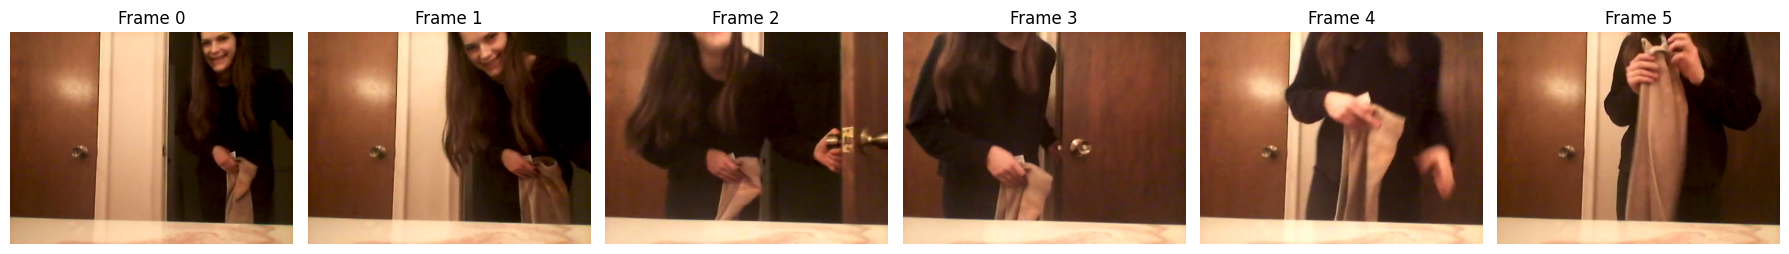

In [50]:
qa_viz.vis_video_frames(gt_df.loc[idx], RAW_VIDEO_DIR, fps=1)


In [51]:
pred_sgg_df.loc[idx]


chat_history           [{'role': 'user', 'content': 'Please carefully...
json_mask                                                           True
contains_answer                                                     True
pred_text                                    Tidy up the closet/cabinet.
q_len                                                                684
reason_len                                                           651
q_len_norm                                                     -0.732916
reason_len_norm                                                 0.564659
q_len_robust_z                                                 -0.591899
reason_len_robust_z                                             2.037521
gt_answer                                       Open the closet/cabinet.
correct                                                                0
Name: Feasibility_T2_556, dtype: object

In [52]:
qa_viz.compact_print_qa(idx, gt_df, [pred_sgg_df])



┌─ Sample: Feasibility_T2_556 ──────────────────────────────────────────────────────────────
│
│ Question:
│    What else is the person able to do with the closet/cabinet?
│ Alternatives:
│    0. Tidy up the closet/cabinet.
│    1. Open the closet/cabinet.
│    2. Close the closet/cabinet.
│    3. Wash the closet/cabinet.
│
│ Ground Truth:
│    Open the closet/cabinet.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  Tidy up the closet/cabinet. [WRONG]
│    Reasoning:
│        Okay, let's analyze the spatio-temporal scene graph and answer the question step-by-step.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "What else is the person able to do with the closet/cabinet?"  It’s looking for actions beyond simply holding the bag. We need to infer what actions are possible based on the scene graph’s depiction of the person’s interactions with the closet.
│        
│        **2. STSG Analysis:**
│        
│        *   **Frame 0:** The per

In [53]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a spatio-temporal scene graph representing the observed interactions, adhering to your guidelines:

<stsg>
Frame 0:
<scene_graph>
person ---- holding ---- bag
bag ---- located_in ---- closet
closet ---- located_in ---- room
room ---- contains ---- door
door ---- is_open ---- false
</scene_graph>
Frame 1:
<scene_graph>
person ---- holding ---- bag
bag ---- being_pulled_from ---- closet
closet ---- located_in ---- room
room ---- contains ---- door
door ---- is_open ---- false
</scene_graph>
Frame 2:
<scene_graph>
person ---- pulling ---- bag
bag ---- located_in ---- closet
closet ---- located_in ---- room
room ---- contains ---- door
door ---- is_open ---- false
</scene_graph>
Frame 3:
<scene_graph>
person ---- reaching_into ---- closet
closet ---- located_in ---- room
room ---- contains ---- door
door ---- is_open ---- false
</scene_gra

### 4

In [60]:
idx = wrongs[3]
idx


'Prediction_T1_2539'

In [61]:
pred_sgg_df.loc[idx]


chat_history           [{'role': 'user', 'content': 'Please carefully...
json_mask                                                           True
contains_answer                                                     True
pred_text                                            None of the others.
q_len                                                               1344
reason_len                                                           406
q_len_norm                                                      0.939878
reason_len_norm                                                -0.629419
q_len_robust_z                                                  1.679342
reason_len_robust_z                                            -1.405187
gt_answer                                              Sit on the floor.
correct                                                                0
Name: Prediction_T1_2539, dtype: object

In [62]:
qa_viz.compact_print_qa(idx, gt_df, [pred_sgg_df])



┌─ Sample: Prediction_T1_2539 ──────────────────────────────────────────────────────────────
│
│ Question:
│    What will the person do next?
│ Alternatives:
│    0. Sit on the floor.
│    1. Open the bag.
│    2. Lie on the bed.
│    3. Tidy up the table.
│
│ Ground Truth:
│    Sit on the floor.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  None of the others. [WRONG]
│    Reasoning:
│        Okay, let's analyze the spatio-temporal scene graph and determine what the person will do next.
│        
│        1. **Question Interpretation:** The question asks what action the person (sitting on the chair) will perform in the next frame, based on the provided scene graphs.
│        
│        2. **STSG Analysis:** The scene graphs consistently show the person sitting on the chair in the garage, within the interior space, which has a pink wall. There's no indication of any change in the person’s location or activity. The scene graph only describes the current state – the person is

In [63]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a spatio-temporal scene graph representing the observed events, adhering to your guidelines:

<stsg>
Frame 0:
<scene_graph>
woman ---- wiping_on ---- car_windshield
car ---- located_in ---- garage
garage ---- located_in ---- interior_space
interior_space ---- has_wall ---- pink_wall
pink_wall ---- has_color ---- pink
</scene_graph>

Frame 1:
<scene_graph>
woman ---- wiping_on ---- car_windshield
car ---- located_in ---- garage
garage ---- located_in ---- interior_space
interior_space ---- has_wall ---- pink_wall
pink_wall ---- has_color ---- pink
person ---- sitting_on ---- chair
chair ---- located_in ---- garage
</scene_graph>

Frame 2:
<scene_graph>
woman ---- wiping_on ---- car_windshield
car ---- located_in ---- garage
garage ---- located_in ---- interior_space
interior_space ---- has_wall ---- pink_wall
pink_wall ---- has_color --

### 5

In [64]:
idx = wrongs[4]
idx


'Interaction_T1_5612'

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/AS7SG.mp4 with start: 22.1, end: 31.0, fps: 1, max_frames: None


	Video Seg:  22.1s - 31.0s


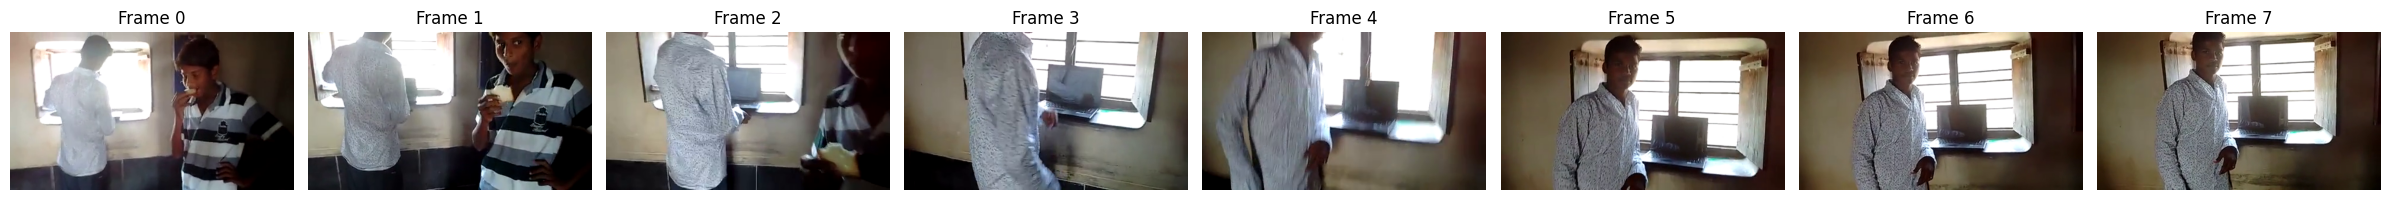

In [65]:
qa_viz.vis_video_frames(gt_df.loc[idx], RAW_VIDEO_DIR, fps=1)


In [66]:
qa_viz.compact_print_qa(idx, gt_df, [pred_sgg_df])



┌─ Sample: Interaction_T1_5612 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was opened by the person?
│ Alternatives:
│    0. The box.
│    1. The window.
│    2. The door.
│    3. The laptop.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The window. [WRONG]
│    Reasoning:
│        Okay, let's analyze the spatio-temporal scene graph to answer the question: “Which object was opened by the person?”
│        
│        **1. Question Interpretation:**
│        
│        The question asks us to identify which object the person interacted with in a way that suggests it was opened. This implies a change of state – from closed to open.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes the following:
│        
│        *   **Man:** Standing near a laptop.
│        *   **Laptop:** On a table.
│        *   **Table:** In front of a window.
│        *   **Window:** Ha

In [67]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Okay, here’s a spatio-temporal scene graph representing the observed events, adhering to your guidelines:

<stsg>
Frame 0:
<scene_graph>
man ---- standing_near ---- laptop
laptop ---- on ---- table
table ---- in_front_of ---- window
window ---- has ---- shutter
shutter ---- partially_open
</scene_graph>
Frame 1:
<scene_graph>
man ---- standing_next_to ---- laptop
laptop ---- on ---- table
table ---- in_front_of ---- window
window ---- has ---- shutter
shutter ---- partially_open
</scene_graph>
Frame 2:
<scene_graph>
man ---- standing_next_to ---- laptop
laptop ---- on ---- table
table ---- in_front_of ---- window
window ---- has ---- shutter
shutter ---- partially_open
</scene_graph>
Frame 3:
<scene_graph>
man ---- standing_next_to ---- laptop
laptop ---- on ---- table
table ---- in_front_of ---- window
window ---- has ---- shutter
shutter --